# TabDDPM

Last of the four generation notebooks, covering the most recent method. Same shape as the
previous three.

TabDDPM is a diffusion model. During training it repeatedly takes a real record, corrupts
it with noise in many small steps until nothing but noise remains, and learns to undo each
step. To generate a record it runs that process in reverse, starting from pure noise and
gradually shaping it into something realistic. The idea powers modern image generators, and
TabDDPM adapts it to tables that mix numbers and categories.

It is included as the recent state-of-the-art method alongside the three established
baselines. Its expected trade-off is computational cost, since generating each record means
running many denoising steps, so both training and generation are slower than the other
methods.

It comes from a different library than the sdv-based methods, which is why the setup below
is more involved and why the session has to restart part way through.

## Setup

synthcity is a large library with many dependencies, so this install takes several minutes
on a fresh session. It only needs to happen once.

Three pinning problems have to be handled together, all caused by the same thing. synthcity
constrains its dependencies to older versions than the environment ships, and pip downgrades
some packages while leaving others untouched, so the set stops matching itself.

1. opacus is pinned because the newer release refers to a part of PyTorch that is not
   present in the version synthcity installs, which would stop the library loading.
2. torch and torchvision have to be installed as a matched pair. synthcity requires torch
   below 2.3, so pip downgrades PyTorch but leaves torchvision, which was compiled against
   the newer one. The import then fails, because torchvision's compiled operators no longer
   match the PyTorch they are registering against.
3. numpy, pandas and pyarrow have to match too. synthcity requires numpy below version 2,
   and the preinstalled pandas and pyarrow are built against numpy 2, so they fail with a
   binary incompatibility error once numpy is downgraded.

The session restart is not optional, and the cell does it automatically. Installing new
versions only replaces the files on disk; the kernel still holds the previous torch and
numpy in memory, and a compiled extension cannot bind to an already imported mismatched
library. Continuing without restarting produces misleading errors that look like a different
problem but are the same one.

So the message about the session restarting is expected rather than a failure. Once it comes
back, skip this cell. Restarting costs nothing, because the training data is read back from
disk rather than held in memory.

In [1]:
# torch and torchvision are pinned as a matched pair. synthcity requires torch<2.3,
# so installing it alone downgrades PyTorch but leaves the installed torchvision, which was
# compiled against the newer PyTorch. The import then fails with
# "RuntimeError: operator torchvision::nms does not exist". Installing them together
# in one resolution pass keeps the compiled operators consistent.
%pip install -q synthcity "opacus==1.5.2" "torch==2.2.2" "torchvision==0.17.2"

# synthcity also requires numpy below version 2, and The preinstalled pandas and pyarrow are
# compiled against numpy 2, so they fail with "ValueError: numpy.dtype size changed"
# once numpy is downgraded. These pins are from the numpy 1.x generation.
%pip install -q "numpy==1.26.4" "pandas==2.1.4" "pyarrow==15.0.2"

# The restart is not optional and cannot be done later. pip has replaced torch and
# numpy on disk, but this kernel still holds the previous versions in memory, and a
# compiled extension cannot bind to an already-imported mismatched library. Skipping
# it produces confusing failures such as "partially initialized module 'torchvision'
# has no attribute 'extension'". Rather than rely on the restart being done by hand,
# this cell performs it itself.
import sys

print(
    "\n"
    "==================================================================\n"
    "  Install finished. RESTARTING THE RUNTIME NOW automatically.\n"
    "\n"
    "  The message about the session restarting is expected, not an\n"
    "  error. When it comes back, skip this cell and continue from\n"
    "  the working folder cell onward.\n"
    "\n"
    "  The training data is read back from disk, so the earlier\n"
    "  steps do not need repeating.\n"
    "==================================================================\n",
    flush=True,
)
sys.stdout.flush()

try:
    from IPython import get_ipython

    get_ipython().kernel.do_shutdown(restart=True)
except Exception:
    print("Automatic restart failed. Restart the session manually.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 7.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 552.2/552.2 kB 53.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.5/118.5 kB 14.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 239.9/239.9 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 1.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 83.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 98.1 MB/s eta 0:00:00:00

## Working folder

Sets the project folder so everything the pipeline writes, the cohort, the synthetic
datasets, the outputs and the figures, persists between sessions rather than sitting on
temporary storage.

The cohort and the synthetic datasets derive from MIMIC-IV, which is credentialed data
under a PhysioNet data use agreement. Keep the folder private, do not share it, and
delete the data once the work is finished.

In [2]:
import os
from pathlib import Path

# Use the shared project folder when one is available, otherwise stay in the
# current directory.
try:
    from google.colab import drive
    drive.mount("/content/drive")
    project_dir = Path("/content/drive/MyDrive/mimic-synthetic-pipeline")
    project_dir.mkdir(parents=True, exist_ok=True)
    os.chdir(project_dir)
    print(f"Working folder: {project_dir}")
except ImportError:
    print("Using the local working folder.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working folder: /content/drive/MyDrive/mimic-synthetic-pipeline


## Hardware check

Hardware matters most for this notebook. Diffusion models are the heaviest method in the
comparison, and on a CPU this run would take hours rather than minutes.

In [5]:
from importlib.metadata import PackageNotFoundError, version

import torch

# Read torchvision's version from its package metadata rather than importing it.
# Importing a mismatched torchvision is itself the failure mode: its compiled
# extension binds to torch at import time, so it hangs or raises rather than
# reporting anything useful. Reading the metadata checks the pairing without
# triggering it.
try:
    torchvision_version = version("torchvision")
except PackageNotFoundError:
    torchvision_version = "not installed"

print(f"torch {torch.__version__}, torchvision {torchvision_version}")
if not (torch.__version__.startswith("2.2") and torchvision_version.startswith("0.17")):
    print(
        "\nWARNING: expected torch 2.2.x paired with torchvision 0.17.x. This pair is\n"
        "mismatched, and synthcity imports torchvision, so it will fail. Delete the\n"
        "runtime and start a fresh session with a GPU, then\n"
        "run the setup cell at the top before anything else."
    )

cuda_available = torch.cuda.is_available()
print(f"CUDA available: {cuda_available}")
if cuda_available:
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print(
        "No GPU detected. TabDDPM will train on CPU, which can take hours on this cohort. "
        "If a GPU was expected, enable it in the session settings, then restart "
        "the session and re-run from the beginning."
    )

torch 2.2.2+cu121, torchvision 0.17.2
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


## Training data

The version check confirms the pins from the setup cell actually took effect, since a
mismatch surfaces later as an opaque binary incompatibility error rather than anything
readable.

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd

# Confirm the install pins took effect. numpy must be below 2 for synthcity, and
# pandas must match it. A mismatch shows up as "ValueError: numpy.dtype size changed".
print(f"numpy {np.__version__}, pandas {pd.__version__}")
if int(np.__version__.split(".")[0]) >= 2:
    raise RuntimeError(
        f"numpy {np.__version__} is too new for synthcity, which requires numpy<2. "
        "Run the setup cell at the top, then restart the session."
    )

if not Path("data/train.parquet").exists():
    raise FileNotFoundError(
        "data/train.parquet not found. Run the extraction and preparation steps first."
    )

TARGET = "readmitted_30d"
train_df = pd.read_parquet("data/train.parquet")

# Guard against pandas nullable Int64 columns (from an older saved train.parquet)
# that some generator libraries cannot read. Coerce them to plain numpy int64.
for _c in train_df.columns:
    if str(train_df[_c].dtype) == "Int64":
        train_df[_c] = train_df[_c].astype("int64")
print(f"Training data: {len(train_df):,} admissions, readmission rate {train_df[TARGET].mean():.4f}")

numpy 1.26.4, pandas 2.1.4
Training data: 428,143 admissions, readmission rate 0.2059


: 

## Diagnostic: which continuous encoder lets the numeric columns train

A diagnostic rather than part of the pipeline proper. It has already been run and its
conclusion is recorded below, so it can be skipped. It is kept because it is the evidence
behind the non-default continuous_encoder setting used further down.

### The problem

A full 1000-epoch run converged, with the loss flat to within 0.03% across the final fifth
of training, but its numeric loss sat at exactly 1.0000 and never moved. For a diffusion
model trained to predict Gaussian noise under a mean-squared-error loss, predicting zero
gives a loss of exactly 1, so that value is the signature of a branch that has learned
nothing at all. The categorical branch trained normally over the same run, so the failure
was specific to the continuous columns and was not a matter of training length.

The consequence was visible in the generated data. Without denoising, variance compounds
through the reverse process and the output is over-dispersed. Mean age came out at 54.0
against a real 58.8, almost exactly the midpoint of the 18 to 91 range, and mean length of
stay at 77.49 days against a real 4.64. No generated value fell outside the real range, so
this was not an artefact of the clipping step further down. Downstream, that dataset
produced a train-on-synthetic ROC AUC of 0.4903, below the 0.5 of random ranking.

### The result

The sweep trains one model per available continuous encoder on a small subsample, so all of
them finish in a few minutes rather than the hours a full run costs, and reports the numeric
loss alongside the mean and standard deviation of the generated numeric columns.

| Encoder | Numeric loss | Categorical loss | Length of stay, mean (real 4.70) | Length of stay, sd (real 6.84) |
|---|---|---|---|---|
| quantile (plugin default) | 0.9536, not learning | 1.0280 | 59.11 | 55.87 |
| bayesian_gmm | 0.8867, learning | 0.2646 | 4.80 | 5.79 |
| passthrough | failed | | | |

bayesian_gmm is therefore the setting used below. The categorical loss improved as well,
from 1.03 to 0.26, so the encoder was degrading both branches rather than only the
continuous one.

passthrough failed for a reason unrelated to this cohort: the library passes a random_state
argument to every feature encoder while the base class does not accept one. It was included
only as a control, and is redundant now that a working encoder has been found.

### Why this matters

The plugin overrides the library's own encoder default in order to force quantile, and under
that setting the method fails silently on this data. It trains without error, reports a
converged loss, and produces a dataset that looks superficially plausible because the
readmission rate and the value ranges are all correct. Only the distribution statistics
reveal the problem. That silence is itself worth reporting.

In [ ]:
import time
import traceback

import torch

print("Importing synthcity (slow on a fresh runtime, up to a few minutes)...", flush=True)
_t = time.time()
from synthcity.plugins import Plugins
from synthcity.plugins.core.dataloader import GenericDataLoader

print(f"  import done in {time.time() - _t:.1f}s", flush=True)

# Deliberately small. This is a yes/no diagnostic about whether the numeric branch
# trains at all, not a quality run, so it is sized to finish in a couple of minutes.
DEBUG_ROWS = 5_000
DEBUG_ITER = 50
DEBUG_TIMESTEPS = 50
DEBUG_BATCH = 512
ENCODERS = ["quantile", "bayesian_gmm", "passthrough"]
NUMERIC_COLS = ["age_at_admission", "length_of_stay_days"]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nSweep on {DEBUG_ROWS:,} rows, {DEBUG_ITER} epochs, device {DEVICE}", flush=True)

debug_df = train_df.sample(n=DEBUG_ROWS, random_state=42).reset_index(drop=True)
real_stats = {c: (debug_df[c].astype(float).mean(), debug_df[c].astype(float).std())
              for c in NUMERIC_COLS}
print("Real subsample:")
for c, (m, s) in real_stats.items():
    print(f"  {c}: mean {m:.2f}, sd {s:.2f}", flush=True)

print("\nBuilding data loader...", flush=True)
debug_loader = GenericDataLoader(debug_df, target_column=TARGET)
print("  loader ready", flush=True)

sweep_rows = []
for encoder in ENCODERS:
    print(f"\n{'=' * 60}\n--- {encoder} ---", flush=True)
    try:
        print("  [1/4] constructing plugin...", flush=True)
        t0 = time.time()
        probe = Plugins().get(
            "ddpm",
            n_iter=DEBUG_ITER,
            batch_size=DEBUG_BATCH,
            num_timesteps=DEBUG_TIMESTEPS,
            device=DEVICE,
            is_classification=True,
            strict=False,
            sampling_patience=1,
            continuous_encoder=encoder,
        )
        print(f"  [2/4] fitting (encoder fit happens first, then the Epoch bar)...", flush=True)
        probe.fit(debug_loader)
        seconds = time.time() - t0
        print(f"  [3/4] fit done in {seconds:.1f}s, generating {DEBUG_ROWS:,} rows...", flush=True)

        history = probe.loss_history
        if history is None:
            history = probe.model.loss_history
        # Average the tail rather than reading one logged point, which is noisy.
        tail = min(5, len(history))
        final_gloss = float(history["gloss"].iloc[-tail:].mean())
        final_mloss = float(history["mloss"].iloc[-tail:].mean())

        sample = probe.generate(count=DEBUG_ROWS).dataframe()
        print(f"  [4/4] generation done", flush=True)

        row = {
            "encoder": encoder,
            "final_gloss": round(final_gloss, 4),
            "final_mloss": round(final_mloss, 4),
            "numeric_learning": final_gloss < 0.95,
            "train_seconds": round(seconds, 1),
        }
        for c in NUMERIC_COLS:
            row[f"{c}_mean"] = round(float(sample[c].astype(float).mean()), 2)
            row[f"{c}_sd"] = round(float(sample[c].astype(float).std()), 2)
        sweep_rows.append(row)

        verdict = "LEARNING" if final_gloss < 0.95 else "NOT LEARNING (trivial solution)"
        print(f"\n  numeric loss {final_gloss:.4f}  ->  {verdict}")
        print(f"  categorical loss {final_mloss:.4f}")
        for c in NUMERIC_COLS:
            rm, rs = real_stats[c]
            print(
                f"  {c}: synthetic mean {row[f'{c}_mean']:>8.2f} sd {row[f'{c}_sd']:>8.2f} "
                f"| real mean {rm:>8.2f} sd {rs:>8.2f}"
            )
    except Exception:
        print(f"  FAILED for encoder={encoder}:")
        traceback.print_exc()
        sweep_rows.append({"encoder": encoder, "final_gloss": None, "numeric_learning": False})
    print(flush=True)

sweep_df = pd.DataFrame(sweep_rows)
out_dir = Path("outputs")
out_dir.mkdir(exist_ok=True)
sweep_df.to_csv(out_dir / "tabddpm_encoder_sweep.csv", index=False)

working = [r["encoder"] for r in sweep_rows if r.get("numeric_learning")]
print("=" * 60)
if working:
    print(f"Encoders whose numeric branch trained: {', '.join(working)}")
    print(f'Set CONTINUOUS_ENCODER = "{working[0]}" in the training cell below.')
else:
    print(
        "No encoder got the numeric loss below 0.95. The numeric branch is not learning\n"
        "regardless of encoding, which points at the library's handling of this data\n"
        "rather than at a tunable setting. Report TabDDPM as a documented\n"
        "implementation failure and keep the three working methods."
    )
sweep_df

Importing synthcity (slow on a fresh runtime, up to a few minutes)...
  import done in 0.0s

Sweep on 5,000 rows, 50 epochs, device cuda
Real subsample:
  age_at_admission: mean 58.69, sd 19.28
  length_of_stay_days: mean 4.70, sd 6.84

Building data loader...
  loader ready

--- quantile ---
  [1/4] constructing plugin...


[2026-07-29T16:53:06.524288+0000][6312][CRITICAL] module disabled: /usr/local/lib/python3.12/dist-packages/synthcity/plugins/generic/plugin_goggle.py


  [2/4] fitting (encoder fit happens first, then the Epoch bar)...


Epoch: 100%|██████████| 50/50 [00:08<00:00,  5.83it/s, loss=1.75]

  [3/4] fit done in 8.7s, generating 5,000 rows...


...

,encoder,final_gloss,final_mloss,numeric_learning,train_seconds,age_at_admission_mean,age_at_admission_sd,length_of_stay_days_mean,length_of_stay_days_sd
0,quantile,0.9589,1.0284,False,8.7,54.77,36.45,57.71,55.92
1,bayesian_gmm,0.8914,0.2657,True,27.5,51.60,33.99,6.61,6.31
2,passthrough,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN


: 

: 

: 

: 

## Hyperparameter search

An earlier round of this project ran every method at library defaults, with the training
budget set by the convergence rule. This section establishes whether TabDDPM performs better under other
settings, so the comparison between methods is not merely a comparison of defaults.

### Method

The search uses successive halving. Every configuration is screened on a small sample at a
reduced budget, and only the strongest few are promoted to a larger sample, the full budget
and repeated seeds. Configurations that look unpromising are therefore abandoned early,
which is where the saving in computation comes from, and the survivors are assessed with
enough repetition that the choice between them is not made on a single noisy run.

Neither library used in this project supports resuming training or validation-based early
stopping at a practical cost, so stopping is applied at the level of the configuration
rather than the epoch. The convergence rule used elsewhere in this project is applied to
each trial's loss curve and reported alongside its score, so a configuration that had not
finished training is visible rather than silently accepted.

Selection uses utility measured on the validation split. The test set is never involved, so
no part of the search can influence the reported results. Fidelity is recorded for every
trial but is not optimised, which means any movement in it is a consequence of selecting for
utility rather than a target of the search. That relationship is itself a finding worth
reporting.

Configurations whose mean scores fall within 0.005 of the best are reported as
indistinguishable, following the same reasoning applied to the differences between methods.
Where several are tied, the simplest should be preferred.

### Parameters varied

The learning rate, weight decay, batch size, the number of denoising steps, and the network itself through `model_params`, which carries the width, depth and dropout. `dim_embed` is varied separately because it sets only the timestep embedding rather than the network capacity. The continuous encoder is held fixed at the value the diagnostic above established on evidence.

### Cost and outputs

Twelve configurations screened, three promoted with three seeds each. This is the most expensive of the four; expect three to four hours.

Three files are written: every individual trial, a summary averaged over seeds, and the
selected configuration as JSON. The training cell below reads the selected
configuration automatically and applies it to the full training split. Nothing here overwrites the saved
synthetic datasets.

In [ ]:
import json
import time

import numpy as np
import pandas as pd
import torch
from pathlib import Path
from scipy.stats import ks_2samp
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# --- Search budget. Reduce these if the search needs to finish sooner. ----------------
SCREEN_ROWS = 25_000     # rows per trial in the screening round
SCREEN_FRACTION = 0.33   # fraction of the full training budget used when screening
PROMOTE_ROWS = 100_000   # rows per trial once a configuration is promoted
PROMOTE_KEEP = 3         # configurations carried into the promotion round
PROMOTE_SEEDS = (0, 1, 2)  # repeats per promoted configuration
TIE_THRESHOLD = 0.005    # ROC AUC difference treated as indistinguishable

NUMERIC_COLS = ["age_at_admission", "length_of_stay_days"]
CATEGORICAL_COLS = [
    "gender", "admission_type", "admission_location", "insurance",
    "marital_status", "race", "language", "had_icu_stay",
]

for _required in ["data/train_fit.parquet", "data/train_val.parquet"]:
    if not Path(_required).exists():
        raise FileNotFoundError(
            f"{_required} not found. Re-run 02_data_preparation.ipynb, which writes the "
            "validation split this search depends on."
        )

fit_df = pd.read_parquet("data/train_fit.parquet")
val_df = pd.read_parquet("data/train_val.parquet")
for _c in fit_df.columns:
    if str(fit_df[_c].dtype) == "Int64":
        fit_df[_c] = fit_df[_c].astype("int64")
        val_df[_c] = val_df[_c].astype("int64")

out_dir = Path("outputs")
out_dir.mkdir(exist_ok=True)

print(f"Fitting split {len(fit_df):,} rows | validation split {len(val_df):,} rows")


def make_classifier() -> Pipeline:
    """The classifier from the main evaluation, so scores are directly comparable."""
    preprocess = ColumnTransformer([
        ("num", StandardScaler(), NUMERIC_COLS),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_COLS),
    ])
    return Pipeline([
        ("preprocess", preprocess),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ])


def utility_on_validation(synthetic: pd.DataFrame) -> float:
    """Train on synthetic, score on the real validation split. The test set is never used."""
    clf = make_classifier()
    clf.fit(synthetic.drop(columns=[TARGET]), synthetic[TARGET])
    proba = clf.predict_proba(val_df.drop(columns=[TARGET]))[:, 1]
    return float(roc_auc_score(val_df[TARGET], proba))


def _tvd(real_col: pd.Series, syn_col: pd.Series) -> float:
    p = real_col.value_counts(normalize=True)
    q = syn_col.value_counts(normalize=True)
    return 0.5 * sum(abs(p.get(c, 0.0) - q.get(c, 0.0)) for c in p.index.union(q.index))


def fidelity_summary(synthetic: pd.DataFrame, real: pd.DataFrame) -> tuple:
    ks = float(np.mean([
        ks_2samp(real[c].astype(float), synthetic[c].astype(float)).statistic
        for c in NUMERIC_COLS
    ]))
    tvd = float(np.mean([
        _tvd(real[c].astype(str), synthetic[c].astype(str)) for c in CATEGORICAL_COLS
    ]))
    return ks, tvd


def converged(loss_series) -> tuple:
    """The stopping rule used elsewhere: mean loss over the final fifth of training
    against the fifth before it. Returns the percentage improvement and a flag."""
    if loss_series is None or len(loss_series) < 10:
        return float("nan"), None
    values = np.asarray(loss_series, dtype=float)
    n = len(values)
    previous = values[int(n * 0.6):int(n * 0.8)].mean()
    final = values[int(n * 0.8):].mean()
    improvement = (previous - final) / abs(previous) * 100
    return float(improvement), bool(improvement <= 1.0)


def set_seed(seed: int) -> None:
    """The sdv synthesizers expose no seed argument, so the global generators are set."""
    np.random.seed(seed)
    torch.manual_seed(seed)


def run_search(space, fit_and_sample, method_slug, full_budget):
    """Successive halving. Every configuration is screened on a small sample at a reduced
    budget; the best few are promoted to a larger sample, a full budget and repeated seeds.
    Unpromising configurations are therefore stopped early, which is where the compute
    saving comes from."""
    screen_sample = fit_df.sample(n=min(SCREEN_ROWS, len(fit_df)), random_state=0).reset_index(drop=True)
    screen_budget = max(1, int(full_budget * SCREEN_FRACTION))

    print(f"\n{'=' * 78}")
    print(f"ROUND 1, screening {len(space)} configurations")
    print(f"{len(screen_sample):,} rows, budget {screen_budget}, one seed each")
    print(f"{'=' * 78}", flush=True)

    screened = []
    for i, (label, config) in enumerate(space, start=1):
        print(f"\n[{i}/{len(space)}] {label}", flush=True)
        t0 = time.time()
        try:
            set_seed(0)
            synthetic, losses = fit_and_sample(config, screen_sample, screen_budget)
            auc = utility_on_validation(synthetic)
            ks, tvd = fidelity_summary(synthetic, screen_sample)
            improvement, is_converged = converged(losses)
            seconds = time.time() - t0
            screened.append({
                "config_label": label, "config": json.dumps(config), "round": "screen",
                "val_roc_auc": auc, "mean_ks": ks, "mean_tvd": tvd,
                "loss_improvement_pct": improvement, "converged": is_converged,
                "seconds": seconds,
            })
            flag = "" if is_converged is None else ("converged" if is_converged else "NOT converged")
            print(f"      ROC AUC {auc:.4f} | KS {ks:.4f} | TVD {tvd:.4f} | {seconds:.0f}s {flag}", flush=True)
        except Exception as exc:  # noqa: BLE001
            print(f"      failed: {type(exc).__name__}: {exc}", flush=True)

    if not screened:
        raise RuntimeError("Every configuration failed during screening.")

    screen_df = pd.DataFrame(screened).sort_values("val_roc_auc", ascending=False)
    promoted = screen_df.head(PROMOTE_KEEP)

    print(f"\n{'=' * 78}")
    print(f"ROUND 2, promoting the top {len(promoted)} of {len(screen_df)}")
    print(f"{min(PROMOTE_ROWS, len(fit_df)):,} rows, budget {full_budget}, "
          f"{len(PROMOTE_SEEDS)} seeds each")
    print(f"{'=' * 78}", flush=True)

    promote_sample = fit_df.sample(n=min(PROMOTE_ROWS, len(fit_df)), random_state=0).reset_index(drop=True)
    promoted_rows = []
    for i, row in enumerate(promoted.itertuples(index=False), start=1):
        config = json.loads(row.config)
        print(f"\n[{i}/{len(promoted)}] {row.config_label}", flush=True)
        for seed in PROMOTE_SEEDS:
            t0 = time.time()
            try:
                set_seed(seed)
                synthetic, losses = fit_and_sample(config, promote_sample, full_budget, seed=seed)
                auc = utility_on_validation(synthetic)
                ks, tvd = fidelity_summary(synthetic, promote_sample)
                improvement, is_converged = converged(losses)
                promoted_rows.append({
                    "config_label": row.config_label, "config": row.config, "round": "promote",
                    "seed": seed, "val_roc_auc": auc, "mean_ks": ks, "mean_tvd": tvd,
                    "loss_improvement_pct": improvement, "converged": is_converged,
                    "seconds": time.time() - t0,
                })
                print(f"      seed {seed}: ROC AUC {auc:.4f} | KS {ks:.4f} | TVD {tvd:.4f}", flush=True)
            except Exception as exc:  # noqa: BLE001
                print(f"      seed {seed} failed: {type(exc).__name__}: {exc}", flush=True)

    promote_df = pd.DataFrame(promoted_rows)
    summary = (
        promote_df.groupby(["config_label", "config"])
        .agg(mean_roc_auc=("val_roc_auc", "mean"), sd_roc_auc=("val_roc_auc", "std"),
             mean_ks=("mean_ks", "mean"), mean_tvd=("mean_tvd", "mean"),
             runs=("val_roc_auc", "size"))
        .reset_index().sort_values("mean_roc_auc", ascending=False)
    )

    pd.concat([screen_df, promote_df], ignore_index=True).to_csv(
        out_dir / f"tuning_{method_slug}_trials.csv", index=False)
    summary.to_csv(out_dir / f"tuning_{method_slug}_summary.csv", index=False)

    print(f"\n{'=' * 78}")
    print("PROMOTION RESULTS, mean over seeds")
    print(f"{'=' * 78}")
    for _, r in summary.iterrows():
        sd = 0.0 if pd.isna(r["sd_roc_auc"]) else r["sd_roc_auc"]
        print(f"  {r['config_label']:<46} {r['mean_roc_auc']:.4f} +/- {sd:.4f}  "
              f"KS {r['mean_ks']:.4f}  TVD {r['mean_tvd']:.4f}  (n={r['runs']})")

    best = summary.iloc[0]
    tied = summary[summary["mean_roc_auc"] >= best["mean_roc_auc"] - TIE_THRESHOLD]

    checkpoint = {
        "method": method_slug,
        "selected_config": json.loads(best["config"]),
        "selected_label": best["config_label"],
        "mean_val_roc_auc": float(best["mean_roc_auc"]),
        "sd_val_roc_auc": None if pd.isna(best["sd_roc_auc"]) else float(best["sd_roc_auc"]),
        "seeds": list(PROMOTE_SEEDS),
        "screen_rows": int(min(SCREEN_ROWS, len(fit_df))),
        "promote_rows": int(min(PROMOTE_ROWS, len(fit_df))),
        "full_budget": full_budget,
        "tied_within_threshold": tied["config_label"].tolist(),
    }
    with open(out_dir / f"tuning_{method_slug}_selected.json", "w", encoding="utf-8") as fh:
        json.dump(checkpoint, fh, indent=2)

    print(f"\nSelected: {best['config_label']}")
    if len(tied) > 1:
        print(f"Within {TIE_THRESHOLD} of the best, so not separable on this evidence:")
        for label in tied["config_label"]:
            print(f"    {label}")
        print("Prefer the simplest of these, and say so in the write-up.")
    print(f"\nSaved outputs/tuning_{method_slug}_selected.json for the final run.")
    return summary


METHOD_SLUG = "tabddpm"
FULL_BUDGET = 1000  # iterations, matching the converged budget used for the reported run

import functools

from synthcity.plugins import Plugins
from synthcity.plugins.core.dataloader import GenericDataLoader

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# model_params carries the network capacity; dim_embed is only the timestep embedding, so
# both are varied. The continuous encoder is held at bayesian_gmm because the diagnostic
# earlier in this notebook settled it on evidence. num_timesteps is included because it
# governs sample quality directly and was reduced during earlier exploratory work.
SEARCH_SPACE = [
    ("reported settings", {}),
    ("lr=0.001", {"lr": 0.001}),
    ("lr=0.005", {"lr": 0.005}),
    ("wide network 512", {"model_params": {"n_units_hidden": 512, "n_layers_hidden": 3, "dropout": 0.0}}),
    ("deep network 5 layers", {"model_params": {"n_units_hidden": 256, "n_layers_hidden": 5, "dropout": 0.0}}),
    ("dropout 0.1", {"model_params": {"n_units_hidden": 256, "n_layers_hidden": 3, "dropout": 0.1}}),
    ("dim_embed=256", {"dim_embed": 256}),
    ("timesteps=500", {"num_timesteps": 500}),
    ("timesteps=2000", {"num_timesteps": 2000}),
    ("batch_size=1024", {"batch_size": 1024}),
    ("weight_decay=1e-3", {"weight_decay": 1e-3}),
    ("lr=0.001 + wide 512", {"lr": 0.001, "model_params": {
        "n_units_hidden": 512, "n_layers_hidden": 3, "dropout": 0.0}}),
]


def fit_and_sample(config, data, budget, seed=0):
    settings = {
        "n_iter": budget,
        "batch_size": 4096,
        "num_timesteps": 1000,
        "device": DEVICE,
        "continuous_encoder": "bayesian_gmm",
        "is_classification": True,
        "strict": False,
        "sampling_patience": 1,
        "random_state": seed,
    }
    settings.update(config)

    model = Plugins().get("ddpm", **settings)
    loader = GenericDataLoader(data, target_column=TARGET)
    model.fit(loader)

    diffusion = model.model.diffusion
    if not getattr(diffusion, "_batch_size_patched", False):
        diffusion.sample_all = functools.partial(diffusion.sample_all, max_batch_size=50_000)
        diffusion._batch_size_patched = True

    synthetic = model.generate(count=len(data)).dataframe()
    synthetic = synthetic[data.columns.tolist()]
    synthetic[TARGET] = synthetic[TARGET].astype(int)

    losses = None
    history = model.loss_history if model.loss_history is not None else model.model.loss_history
    if history is not None:
        losses = history["loss"].to_numpy()
    return synthetic, losses

summary = run_search(SEARCH_SPACE, fit_and_sample, METHOD_SLUG, FULL_BUDGET)
summary


: 

: 

: 

: 

## Fitting

The data loader is told which column is the prediction target, and is_classification makes
the library treat it as a class label so generation is conditioned on the outcome. Without
that flag the outcome is modelled as an ordinary numeric column.

continuous_encoder decides whether this method works at all on this cohort. The plugin's
own default of quantile left the continuous branch stuck at the trivial solution through a
full 1000-epoch run, producing a mean length of stay of 77 days against a real 4.6. The
sweep above identified bayesian_gmm as the encoder under which the numeric branch actually
trains. This is a documented deviation from the library default, made on the evidence in
that sweep.

n_iter is the number of passes over the data, not batches. The convergence check below
decides whether the count was enough. num_timesteps is the number of denoising steps and
stays at the library default; generation is cheap once the generation batch size further
down is raised, so sample quality does not have to be traded away for it.

Fitting and generation are kept in separate cells so that a problem during generation does
not cost the training run.

In [ ]:
import time

import torch

from synthcity.plugins import Plugins
from synthcity.plugins.core.dataloader import GenericDataLoader

# Set from the diagnostic sweep above. The plugin's own default is "quantile", under
# which the numeric loss stayed pinned at 1.0 for a full 1000-epoch run and the
# continuous branch never learned: generated length of stay averaged 59 days against
# a real 4.7. With "bayesian_gmm" the numeric loss falls and length of stay comes back
# at 4.80 against a real 4.70 after only 50 epochs on a 5,000-row subsample. The
# categorical loss improved as well, from 1.03 to 0.26, so the encoder was degrading
# both branches rather than only the numeric one.
CONTINUOUS_ENCODER = "bayesian_gmm"

N_ITER = 1000           # Lower than the 1000 used with the quantile encoder. bayesian_gmm
                      # expands each numeric column into several input dimensions, so it
                      # trains roughly 2.5x slower per epoch, but it also learns far more
                      # per epoch. Check the convergence cell below: if the final fifth is
                      # still improving by more than 1%, raise this and re-run.
BATCH_SIZE = 4096     # records per training step
NUM_TIMESTEPS = 1000  # denoising steps, the library default. Generation is cheap once the
                      # generation batch size further down is raised, so the full step
                      # count costs only a couple of minutes.

# Use the GPU if one is available. This is essential: the library defaults to
# the CPU, on which training and especially generation of a dataset this size
# take hours. On a GPU they take minutes.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
import json as _json

# Set to False to reproduce the library-default run rather than the tuned one.
USE_TUNED_CONFIG = True

TUNED = {}
CONFIG_LABEL = "library defaults"
_selected = Path("outputs/tuning_tabddpm_selected.json")
if USE_TUNED_CONFIG and _selected.exists():
    with open(_selected, encoding="utf-8") as _fh:
        _payload = _json.load(_fh)
    TUNED = _payload["selected_config"]
    CONFIG_LABEL = _payload["selected_label"]
    print(f"Using the configuration chosen by the search: {CONFIG_LABEL}")
    print(f"  {TUNED}")
elif USE_TUNED_CONFIG:
    print("No search result found, so the library defaults are used.")
    print(f"  Run the search section at the end of this notebook to produce {_selected}.")
else:
    print("USE_TUNED_CONFIG is False, so the library defaults are used.")

print(f"Training TabDDPM on: {DEVICE}, continuous encoder: {CONTINUOUS_ENCODER}")

loader = GenericDataLoader(train_df, target_column=TARGET)

settings = {
    "n_iter": N_ITER,
    "batch_size": BATCH_SIZE,
    "num_timesteps": NUM_TIMESTEPS,
    "device": DEVICE,
    "continuous_encoder": CONTINUOUS_ENCODER,
    # Treat readmission as the class label, so generation is conditioned on the outcome
    # rather than modelling it as a plain numeric column.
    "is_classification": True,
    # Both of these disable the library's internal resampling loop, which silently
    # regenerates the entire dataset until enough rows survive its own filters. That
    # loop, not the training, is what caused this notebook to hang previously.
    "strict": False,
    "sampling_patience": 1,
}
# Anything chosen by the search overrides the values above.
settings.update(TUNED)

model = Plugins().get("ddpm", **settings)

t0 = time.time()
model.fit(loader)
train_seconds = time.time() - t0

print(f"Training took {train_seconds:.1f}s")

[2026-07-29T17:02:59.702718+0000][6312][CRITICAL] module disabled: /usr/local/lib/python3.12/dist-packages/synthcity/plugins/generic/plugin_goggle.py


Training TabDDPM on: cuda, continuous encoder: bayesian_gmm


Epoch: 100%|██████████| 1000/1000 [2:41:18<00:00,  9.68s/it, loss=0.368]

Training took 9809.1s


: 

: 

: 

: 

## Training convergence

n_iter is the main quality lever for this method, so it needs evidence behind it. This
plots the loss curve and, more usefully, quantifies it, comparing the mean loss over the
final fifth of training against the fifth before it.

The objective is a denoising loss with no adversarial component, so it can be read the
ordinary way: still falling appreciably at the end means undertrained. It has two parts,
one for the numeric columns and one for the categorical columns, and they converge at
different rates, so all three series are plotted. If the categorical part is still
descending while the numeric part has flattened, the categorical columns are the binding
constraint on training length.

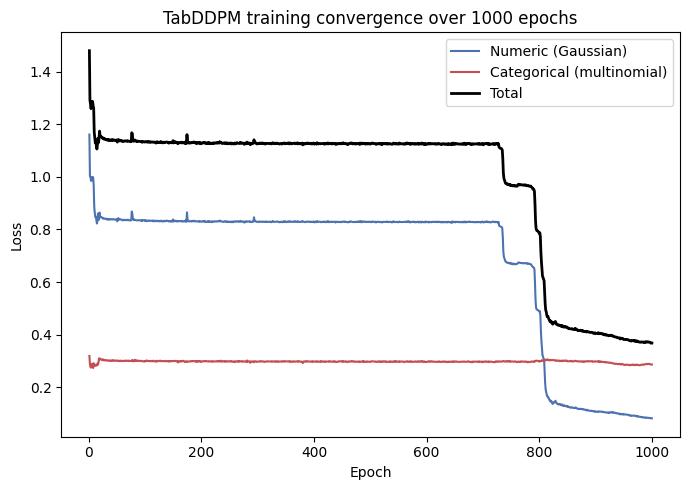

Total        prev fifth    1.0668 | final fifth    0.4180 | change +60.82%  (still improving)
Numeric      prev fifth    0.7696 | final fifth    0.1234 | change +83.96%  (still improving)
Categorical  prev fifth    0.2972 | final fifth    0.2945 | change  +0.90%  (flat)

Any series still improving by more than 1% across the final fifth means N_ITER=1000 is too low for that part of the model. Raising N_ITER costs training time only; generation time is unaffected.

Watch the Numeric row in particular. Under the plugin's default 'quantile'
encoder it sat at exactly 1.0000, the trivial solution, meaning that branch had
learned nothing at all. With 'bayesian_gmm' it should be well below 1.

Saved loss history to outputs/loss_history_tabddpm.csv


: 

: 

: 

: 

In [ ]:
import math

import matplotlib.pyplot as plt

fig_dir = Path("figures")
fig_dir.mkdir(exist_ok=True)
out_dir = Path("outputs")
out_dir.mkdir(exist_ok=True)

# The plugin copies the model's history up after fitting; fall back to the inner
# model if that ever changes upstream.
loss_history = model.loss_history
if loss_history is None:
    loss_history = model.model.loss_history

# The history is indexed by optimiser step. Convert to epochs so this chart is
# directly comparable with the CTGAN and TVAE convergence charts.
steps_per_epoch = math.ceil(len(train_df) / BATCH_SIZE)
epochs_axis = loss_history.index / steps_per_epoch

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(epochs_axis, loss_history["gloss"], label="Numeric (Gaussian)", color="#4C72B0")
ax.plot(epochs_axis, loss_history["mloss"], label="Categorical (multinomial)", color="#C44E52")
ax.plot(epochs_axis, loss_history["loss"], label="Total", color="black", linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title(f"TabDDPM training convergence over {N_ITER} epochs")
ax.legend()
fig.tight_layout()
fig.savefig(fig_dir / "training_convergence_tabddpm.png", dpi=150)
plt.show()

# The convergence verdict is computed and printed BEFORE anything is written to disk,
# so a file-writing problem cannot cost the diagnostic after an hour of training. Same
# final-fifth comparison as the TVAE notebook, so the two are read the same way.
for label, series in [
    ("Total", loss_history["loss"]),
    ("Numeric", loss_history["gloss"]),
    ("Categorical", loss_history["mloss"]),
]:
    n = len(series)
    prev_fifth = series.iloc[int(n * 0.6):int(n * 0.8)].mean()
    last_fifth = series.iloc[int(n * 0.8):].mean()
    improvement = (prev_fifth - last_fifth) / abs(prev_fifth) * 100
    flag = "still improving" if improvement > 1.0 else "flat"
    print(
        f"{label:<12} prev fifth {prev_fifth:>9.4f} | final fifth {last_fifth:>9.4f} "
        f"| change {improvement:+6.2f}%  ({flag})"
    )

print(
    f"\nAny series still improving by more than 1% across the final fifth means "
    f"N_ITER={N_ITER} is too low for that part of the model. Raising N_ITER costs "
    f"training time only; generation time is unaffected."
)
print(
    "\nWatch the Numeric row in particular. Under the plugin's default 'quantile'\n"
    "encoder it sat at exactly 1.0000, the trivial solution, meaning that branch had\n"
    "learned nothing at all. With 'bayesian_gmm' it should be well below 1."
)

# Saving the raw values is a convenience, not a result, so it must not be able to stop
# this cell. Rebuilding the frame with plain string column names avoids a pandas
# internal failure seen in the sdv notebooks ("AttributeError: 'Index' object has no
# attribute '_format_native_types'"), and any remaining failure is caught and reported.
try:
    to_save = loss_history.reset_index()
    to_save.columns = [str(c) for c in to_save.columns]
    to_save.to_csv(out_dir / "loss_history_tabddpm.csv", index=False)
    print(f"\nSaved loss history to {out_dir / 'loss_history_tabddpm.csv'}")
except Exception as exc:  # noqa: BLE001
    print(f"\nCould not write the loss history CSV ({type(exc).__name__}: {exc}).")
    print("The convergence numbers above are unaffected.")

## Generating

Generation is requested in chunks rather than as one call for the whole cohort. The library
generates internally in fixed batches of 2,000 records with no progress reporting, so a
single call for the full dataset produces no output for a long time and is
indistinguishable from a frozen session. Asking for it a chunk at a time gives a visible
progress line and an estimate of the time left.

The three sdv-based methods keep generated values inside the range seen in the real data.
Once this library's internal filtering is switched off it does not, so the same bound is
applied explicitly and the number of values affected is recorded. That proportion is itself
a fidelity result, because clipping piles out-of-range values onto the boundaries and
inflates the KS statistic, so a large figure would mean part of that statistic reflects
processing rather than the model.

In [ ]:
import functools

CHUNK_SIZE = 50_000  # rows requested per call, purely so progress is visible

# synthcity hardcodes an internal generation batch of 2,000 rows inside sample_all
# and does not expose it as a parameter. That leaves the GPU almost idle: every
# denoising step is a small network forward, so the run time is set by how many
# sequential steps there are rather than by arithmetic. Raising the batch cuts the
# number of those steps proportionally, which is the largest single speed-up
# available here and matters far more than which GPU the session is allocated.
_diffusion = model.model.diffusion
if not getattr(_diffusion, "_batch_size_patched", False):
    _diffusion.sample_all = functools.partial(
        _diffusion.sample_all, max_batch_size=CHUNK_SIZE
    )
    _diffusion._batch_size_patched = True

n_total = len(train_df)
pieces = []

t0 = time.time()
for start in range(0, n_total, CHUNK_SIZE):
    n = min(CHUNK_SIZE, n_total - start)
    pieces.append(model.generate(count=n).dataframe())

    done = start + n
    elapsed = time.time() - t0
    remaining = (elapsed / done) * (n_total - done)
    print(
        f"  {done:,}/{n_total:,} rows | {elapsed / 60:.1f} min elapsed, "
        f"~{remaining / 60:.1f} min remaining",
        flush=True,
    )
generate_seconds = time.time() - t0

synthetic_df = pd.concat(pieces, ignore_index=True)
synthetic_df = synthetic_df[train_df.columns.tolist()]
synthetic_df[TARGET] = synthetic_df[TARGET].astype(int)

# Match the other three methods, which keep generated values inside the range
# observed in the real data. Recorded to disk rather than only printed, because the
# proportion clipped is itself a fidelity result: clipping piles out-of-range values
# onto the boundaries, which inflates the KS statistic in 07_evaluation.ipynb. A
# large figure here means part of that KS number reflects this processing step
# rather than the model, and must be reported alongside it.
clip_rows = []
for col in ["age_at_admission", "length_of_stay_days"]:
    lo = float(train_df[col].astype(float).min())
    hi = float(train_df[col].astype(float).max())
    values = synthetic_df[col].astype(float)
    n_below = int((values < lo).sum())
    n_above = int((values > hi).sum())
    synthetic_df[col] = values.clip(lo, hi)
    clip_rows.append({
        "column": col,
        "real_min": lo,
        "real_max": hi,
        "n_below_min": n_below,
        "n_above_max": n_above,
        "pct_clipped": round((n_below + n_above) / len(synthetic_df) * 100, 4),
    })
    print(
        f"{col}: {n_below + n_above:,} values "
        f"({(n_below + n_above) / len(synthetic_df):.2%}) clipped to [{lo:.2f}, {hi:.2f}] "
        f"({n_below:,} below, {n_above:,} above)"
    )

out_dir = Path("outputs")
out_dir.mkdir(exist_ok=True)
pd.DataFrame(clip_rows).to_csv(out_dir / "tabddpm_clip_report.csv", index=False)

synthetic_df.to_parquet("data/synthetic_tabddpm.parquet", index=False)

print(f"\nTraining took {train_seconds:.1f}s, generation took {generate_seconds:.1f}s")
print(f"Saved {len(synthetic_df):,} synthetic admissions to data/synthetic_tabddpm.parquet")

  50,000/427,408 rows | 0.5 min elapsed, ~3.8 min remaining
  100,000/427,408 rows | 1.0 min elapsed, ~3.3 min remaining
  150,000/427,408 rows | 1.5 min elapsed, ~2.8 min remaining
  200,000/427,408 rows | 2.0 min elapsed, ~2.3 min remaining
  250,000/427,408 rows | 2.5 min elapsed, ~1.8 min remaining
  300,000/427,408 rows | 3.0 min elapsed, ~1.3 min remaining
  350,000/427,408 rows | 3.5 min elapsed, ~0.8 min remaining
  400,000/427,408 rows | 4.0 min elapsed, ~0.3 min remaining
  427,408/427,408 rows | 4.4 min elapsed, ~0.0 min remaining
age_at_admission: 0 values (0.00%) clipped to [18.00, 91.00] (0 below, 0 above)
length_of_stay_days: 0 values (0.00%) clipped to [0.00, 515.54] (0 below, 0 above)

Training took 9809.1s, generation took 264.0s
Saved 427,408 synthetic admissions to data/synthetic_tabddpm.parquet


: 

: 

: 

: 

## Sanity checks

Quick aggregate checks before the full evaluation.

In [ ]:
checks = pd.DataFrame({
    "statistic": ["Readmission rate", "Mean age", "Mean length of stay (days)"],
    "real_training_data": [
        round(train_df[TARGET].mean(), 4),
        round(train_df["age_at_admission"].astype(float).mean(), 1),
        round(train_df["length_of_stay_days"].mean(), 2),
    ],
    "synthetic_data": [
        round(synthetic_df[TARGET].mean(), 4),
        round(synthetic_df["age_at_admission"].astype(float).mean(), 1),
        round(synthetic_df["length_of_stay_days"].mean(), 2),
    ],
})
checks

,statistic,real_training_data,synthetic_data
0,Readmission rate,0.2067,0.2064
1,Mean age,58.8000,61.0000
2,Mean length of stay (days),4.6400,3.3700


: 

: 

: 

: 

In [ ]:
# Record the hardware alongside the timings. Without it the cost comparison in the
# results chapter rests on recollection of which session used which accelerator.
try:
    import torch as _torch
    GPU_NAME = _torch.cuda.get_device_name(0) if _torch.cuda.is_available() else "CPU"
except Exception:  # noqa: BLE001
    GPU_NAME = "unknown"

# Append this run's timings to the shared generation log used by all four methods.
out_dir = Path("outputs")
out_dir.mkdir(exist_ok=True)
log_path = out_dir / "generation_log.csv"

entry = pd.DataFrame([{
    "method": "TabDDPM",
    "rows_generated": len(synthetic_df),
    "train_seconds": round(train_seconds, 1),
    "generate_seconds": round(generate_seconds, 1),
    "gpu": GPU_NAME,
    "config": CONFIG_LABEL,
}])
if log_path.exists():
    log = pd.read_csv(log_path)
    # Keyed on method and configuration, so the default and tuned runs both survive.
    if "config" in log.columns:
        log = log[~((log["method"] == "TabDDPM") & (log["config"] == CONFIG_LABEL))]
    else:
        log = log[log["method"] != "TabDDPM"]
    log = pd.concat([log, entry], ignore_index=True)
else:
    log = entry
log.to_csv(log_path, index=False)
log

,method,rows_generated,train_seconds,generate_seconds
0,CTGAN,427408,6724.9,5.5
1,Gaussian Copula,427408,105.5,7.3
2,TVAE,427408,4223.3,3.1
3,TabDDPM,427408,9809.1,264.0


: 

: 

: 

: 

The log now holds the computational cost of all four methods side by side, which becomes
part of the comparison: a method's quality scores have to be weighed against what it costs
to run.